In [ ]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

2026-03-09 11:10:20.878476: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 11:10:20.878895: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 11:10:20.881205: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 11:10:20.887330: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773025820.897739  143806 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773025820.90

# Specify each path

In [ ]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keyp/keypoint_classifier.h5'
tflite_save_path = 'model/keyp/keypoint_classifier.tflite'

# Set number of classes

In [ ]:
NUM_CLASSES = 5

# Dataset reading

In [ ]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [ ]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

In [ ]:
print('X_dataset shape:', X_dataset.shape)
print('y_dataset shape:', y_dataset.shape)
unique_labels, counts = np.unique(y_dataset, return_counts=True)
print('Class distribution:', dict(zip(unique_labels.tolist(), counts.tolist())))

X_dataset shape: (3505, 42)
y_dataset shape: (3505,)
Class distribution: {0: 1522, 1: 1572, 2: 411}


# Model building

Set `use_lstm = True` in the next cell to switch from the default MLP to an LSTM-based model over the 21 hand landmarks.

In [ ]:
use_lstm = True
model = None

if use_lstm:
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(21 * 2,)),
        tf.keras.layers.Reshape((21, 2)),
        
        # 移除 Bidirectional，改回單向 LSTM 
        # 並加上 unroll=True (這能幫助 TFLite 靜態展開，大幅提高轉換成功率)
        tf.keras.layers.LSTM(64, return_sequences=False, unroll=True), 
        
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
        ])
else:
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input((21 * 2, )),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(20, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

In [ ]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_7 (Reshape)             │ (None, 21, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,653 (76.77 KB)

 Trainable params: 19,525 (76.27 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [ ]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
15/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2887 - loss: 1.5714
Epoch 1: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4326 - loss: 1.3117 - val_accuracy: 0.5097 - val_loss: 1.4001
Epoch 2/1000
16/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5755 - loss: 0.9725
Epoch 2: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5955 - loss: 0.9201 - val_accuracy: 0.5245 - val_loss: 1.2541
Epoch 3/1000
17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6225 - loss: 0.8278
Epoch 3: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6530 - loss: 0.7813 - val_accuracy: 0.5211 - val_loss: 1.2075
Epoch 4/1000
17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6756 - loss: 0.7184
Epoch 4: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7154 - loss: 0.6767 - val_accuracy: 0.5428 - val_loss: 1.1457
Epoch 5/1000
16/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7588 - loss: 0.5968
Epoch 5: saving model to model/keyp/keypoint_classifier.h5


...

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9756 - loss: 0.0592 - val_accuracy: 0.9818 - val_loss: 0.0637
Epoch 68/1000
15/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9847 - loss: 0.0517
Epoch 68: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9833 - loss: 0.0497 - val_accuracy: 0.9897 - val_loss: 0.0514
Epoch 69/1000
18/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9856 - loss: 0.0415
Epoch 69: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9867 - loss: 0.0407 - val_accuracy: 0.9852 - val_loss: 0.0453
Epoch 70/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9876 - loss: 0.0437
Epoch 70: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9867 - loss: 0.0429 - val_accuracy: 0.9726 - val_loss: 0.0634
Epoch 71/1000


KeyboardInterrupt: 

In [ ]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9897 - loss: 0.0259 


In [ ]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [ ]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
[2.8575872e-05 2.9082358e-08 6.5361174e-09 9.9997139e-01 2.4410333e-08]
3


# Confusion matrix

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


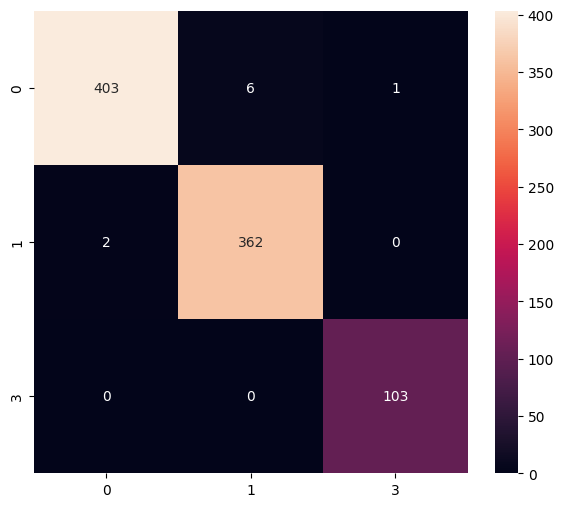

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       410
           1       0.98      0.99      0.99       364
           3       0.99      1.00      1.00       103

    accuracy                           0.99       877
   macro avg       0.99      0.99      0.99       877
weighted avg       0.99      0.99      0.99       877



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [ ]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [ ]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /tmp/tmpcctf2d2g/assets


INFO:tensorflow:Assets written to: /tmp/tmpcctf2d2g/assets


Saved artifact at '/tmp/tmpcctf2d2g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_13')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132601792950544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601791702192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601791703424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601146032544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601146035888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601146033600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601146034656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601146046096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601146046800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601146263680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132601146264384: Tens

W0000 00:00:1773025494.559570    7034 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773025494.559580    7034 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-03-09 11:04:54.559690: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpcctf2d2g
2026-03-09 11:04:54.560469: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-09 11:04:54.560475: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpcctf2d2g
2026-03-09 11:04:54.569197: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-09 11:04:54.598897: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpcctf2d2g
2026-03-09 11:04:54.612584: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 52896 microseconds.


88904

# Inference test

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

/home/ocarpan/Documents/hand-gesture-recognition-mediapipe/venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [ ]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 592 μs, sys: 50 μs, total: 642 μs
Wall time: 314 μs


In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[2.7455895e-05 2.6864715e-08 5.8868586e-09 9.9997246e-01 2.2447553e-08]
3


In [ ]:
#read keypoint databse

